# 05 — Multiclass SVM Loss

A linear classifier produces scores, but scores alone do not tell us whether parameters are good. A loss function converts those scores and the correct labels into one scalar measuring model error.

This notebook introduces the multiclass support vector machine (SVM) loss, also called multiclass hinge loss. Gradients and optimization are intentionally deferred to the next practice.

## Learning objectives

- interpret the SVM margin requirement;
- compute per-class and per-example hinge losses;
- implement naïve and vectorized batch losses;
- distinguish data loss from regularization loss;
- test useful invariants of the loss;
- understand why near-zero random scores produce loss near `C - 1`.

In [98]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from torchvision.datasets import CIFAR10

SEED = 42
rng = np.random.default_rng(SEED)
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"

## 1. The margin requirement

For example `i`, let $s_{y_i}$ be the correct-class score and $s_j$ an incorrect-class score. We want the correct score to exceed every incorrect score by at least a margin $\Delta$:

$$s_{y_i} \ge s_j + \Delta.
$$

A violation contributes hinge loss

$$L_{i,j}=\max(0, s_j-s_{y_i}+\Delta).
$$

The loss for one example sums over incorrect classes only:

$$L_i=\sum_{j\ne y_i}\max(0,s_j-s_{y_i}+\Delta).
$$

We use $\Delta=1$. The numerical choice fixes a score scale; multiplying both the parameters and margin by the same positive factor preserves the equivalent constraint.

### Exercise 1 — One example by hand

Suppose the scores for `[cat, car, frog]` are `[3.2, 5.1, -1.7]` and the correct class is `cat`. With $\Delta=1$:

1. calculate the margin for `car`;
2. calculate the margin for `frog`;
3. apply the hinge to both margins;
4. calculate the total loss.

Write the arithmetic in a Markdown cell before running the check below.

In [99]:
scores_example = np.array([3.2, 5.1, -1.7])
correct_class = 0
delta = 1.0

car_loss = np.maximum(0, scores_example[1] - scores_example[correct_class] + delta)
frog_loss = np.maximum(0, scores_example[2] - scores_example[correct_class] + delta)
example_loss = car_loss + frog_loss

assert np.isclose(car_loss, 2.9)
assert np.isclose(frog_loss, 0.0)
assert np.isclose(example_loss, 2.9)
print("Example loss:", example_loss)

Example loss: 2.8999999999999995


## 2. What zero loss means

Zero loss does not merely mean that the correct class has the largest score. It means that the correct score is at least $\Delta$ larger than every incorrect score. Once an example satisfies all margins, increasing its correct score further does not reduce its SVM data loss below zero.

This creates a flat region in the objective: many different score vectors can have identical zero loss.

### Exercise 2 — Implement one-example loss

Implement the formula directly. Validate that `scores` is one-dimensional, the label is valid, and `delta` is positive. Do not include the correct class in the sum.

In [100]:
def svm_loss_one(scores: np.ndarray, correct_label: int, delta: float = 1.0) -> float:
    """Return multiclass hinge loss for one example."""
    if not isinstance(scores, np.ndarray):
        raise TypeError("Scores must be a numpy array.")
    if not isinstance(correct_label, (int, np.integer)):
        raise TypeError("Correct label must be an integer.")
    if correct_label < 0 or correct_label >= len(scores):
        raise ValueError("Correct label must be a valid index in scores.")
    if not isinstance(delta, (int, float)):
        raise TypeError("Delta must be a number.")
    if delta <= 0:
        raise ValueError("Delta must be positive.")
    if scores.ndim != 1:
        raise ValueError("Scores must be a 1D array.")
    if scores.size == 0:
        raise ValueError("Scores must not be empty.")

    return np.sum(np.maximum(0, scores - scores[correct_label] + delta)) - delta


assert np.isclose(svm_loss_one(scores_example, correct_class), 2.9)
assert svm_loss_one(np.array([4.0, 2.0, 1.0]), correct_label=0) == 0.0
print("One-example checks passed.")

One-example checks passed.


### Why does this implementation subtract `delta`?

The vector expression initially computes a margin for every class, including the correct class. At the correct index,

$$\max(0,s_y-s_y+\Delta)=\max(0,\Delta)=\Delta.
$$

The SVM formula sums only over $j\ne y$, so that extra correct-class contribution must be removed. Subtracting `delta` after the sum does exactly that when `delta` is positive. For the example, the temporary margins are `[1.0, 2.9, 0.0]`; their sum is `3.9`, and subtracting `1.0` gives the intended loss `2.9`.

An equivalent and often clearer implementation explicitly sets the correct entry to zero before summing:

```python
margins = np.maximum(0, scores - scores[correct_label] + delta)
margins[correct_label] = 0
return float(margins.sum())
```

## 3. Batch loss with explicit loops

For `N` examples and `C` classes, `scores` has shape `(N, C)` and `labels` has shape `(N,)`. The batch data loss is the mean of the example losses:

$$L_{data}=\frac{1}{N}\sum_{i=1}^{N}L_i.
$$

Averaging makes the scale less dependent on batch size.

### Exercise 3 — Naïve batch implementation

Use two loops: one over examples and one over classes. This will become the readable reference for the vectorized version.

In [101]:
def svm_loss_naive(scores: np.ndarray, labels: np.ndarray, delta: float = 1.0) -> float:
    """Return mean multiclass SVM data loss using explicit loops."""
    if scores.ndim != 2:
        raise ValueError("Scores must be a 2D array.")
    if labels.ndim != 1:
        raise ValueError("Labels must be a 1D array.")
    if scores.shape[0] != labels.shape[0]:
        raise ValueError("Number of scores must match number of labels.")
    if scores.shape[0] == 0 or scores.shape[1] == 0:
        raise ValueError("Scores and labels must not be empty.")
    if not np.issubdtype(labels.dtype, np.integer):
        raise TypeError("Labels must contain integers.")
    if np.any((labels < 0) | (labels >= scores.shape[1])):
        raise ValueError("Labels must be valid class indices.")
    if not isinstance(delta, (int, float, np.number)):
        raise TypeError("Delta must be a number.")
    if delta <= 0:
        raise ValueError("Delta must be positive.")

    loss = 0.0
    for i in range(scores.shape[0]):
        correct_class_score = scores[i, labels[i]]
        for j in range(scores.shape[1]):
            if j == labels[i]:
                continue
            margin = scores[i, j] - correct_class_score + delta
            if margin > 0:
                loss += margin

    return loss / scores.shape[0]


scores_small = np.array([
    [3.2, 5.1, -1.7],
    [1.3, 2.0, 4.2],
    [0.5, 0.1, -0.2],
])
labels_small = np.array([0, 2, 1])

naive_loss = svm_loss_naive(scores_small, labels_small)
print("Naïve batch loss:", naive_loss)

Naïve batch loss: 1.6666666666666663


## 4. Vectorizing the margins

The vectorized calculation follows the formula while tracking shapes:

1. `scores[np.arange(N), labels]` selects correct scores with shape `(N,)`.
2. Reshaping them to `(N, 1)` allows subtraction from every class column.
3. `scores - correct_scores + delta` produces all margins with shape `(N, C)`.
4. The correct-class entries must be set to zero because the formula excludes $j=y_i$.
5. Applying `maximum(0, margins)` and averaging the total gives the data loss.

Before step 4, a correct-class margin equals $s_{y_i}-s_{y_i}+\Delta=\Delta$, not zero. Excluding it explicitly is therefore essential.

### Exercise 4 — Vectorized batch implementation

Implement the five steps without Python loops. Keep the intermediate `margins` matrix available for inspection.

In [102]:
np.arange(scores_small.shape[0]), labels_small

(array([0, 1, 2]), array([0, 2, 1]))

In [103]:
scores_small[np.arange(scores_small.shape[0]), labels_small]

array([3.2, 4.2, 0.1])

In [104]:
scores_small[np.arange(scores_small.shape[0]), labels_small].reshape(-1, 1), scores_small[np.arange(scores_small.shape[0]), labels_small][:, np.newaxis]

(array([[3.2],
        [4.2],
        [0.1]]),
 array([[3.2],
        [4.2],
        [0.1]]))

In [105]:
def svm_margins(scores: np.ndarray, labels: np.ndarray, delta: float = 1.0) -> np.ndarray:
    """Return the nonnegative margin matrix with a zero correct column per row."""
    if scores.ndim != 2:
        raise ValueError("Scores must be a 2D array.")
    if labels.ndim != 1:
        raise ValueError("Labels must be a 1D array.")
    if scores.shape[0] != labels.shape[0]:
        raise ValueError("Number of scores must match number of labels.")
    if scores.shape[0] == 0 or scores.shape[1] == 0:
        raise ValueError("Scores and labels must not be empty.")
    if not np.issubdtype(labels.dtype, np.integer):
        raise TypeError("Labels must contain integers.")
    if np.any((labels < 0) | (labels >= scores.shape[1])):
        raise ValueError("Labels must be valid class indices.")
    if not isinstance(delta, (int, float, np.number)):
        raise TypeError("Delta must be a number.")
    if delta <= 0:
        raise ValueError("Delta must be positive.")

    scores_correct = scores[np.arange(scores.shape[0]), labels][:, np.newaxis] # simiral to .reshape(-1, 1)
    margins = np.maximum(0, scores - scores_correct + delta)
    margins[np.arange(scores.shape[0]), labels] = 0
    return margins


def svm_loss_vectorized(scores: np.ndarray, labels: np.ndarray, delta: float = 1.0) -> float:
    """Return mean multiclass SVM data loss without Python loops."""
    return np.mean(
        np.sum(
            svm_margins(scores, labels, delta),
            axis=1
        )
    )


margins_small = svm_margins(scores_small, labels_small)
vectorized_loss = svm_loss_vectorized(scores_small, labels_small)
np.testing.assert_allclose(vectorized_loss, naive_loss)
assert margins_small.shape == scores_small.shape
assert np.all(margins_small[np.arange(len(labels_small)), labels_small] == 0)
print("Margins:\n", margins_small)
print("Vectorized loss:", vectorized_loss)

Margins:
 [[0.  2.9 0. ]
 [0.  0.  0. ]
 [1.4 0.  0.7]]
Vectorized loss: 1.6666666666666663


### Per-example contributions

The batch loss is an average, but individual examples can contribute very different amounts. Summing each row of the margin matrix recovers its example loss. A zero-height bar means that example satisfies every required margin.

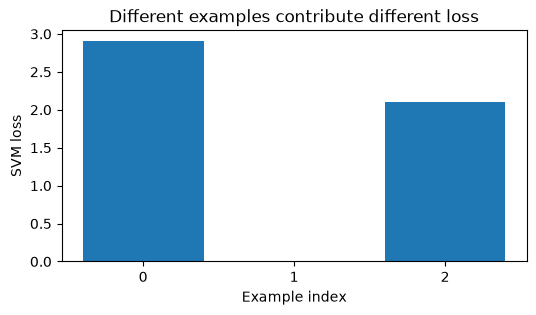

In [106]:
example_losses = margins_small.sum(axis=1)
fig, axis = plt.subplots(figsize=(6, 3))
axis.bar(np.arange(len(example_losses)), example_losses)
axis.set(
    xlabel="Example index",
    ylabel="SVM loss",
    title="Different examples contribute different loss",
)
axis.set_xticks(np.arange(len(example_losses)))
plt.show()

## 5. Exercise 5 — Loss invariants

Use assertions to verify these properties:

1. adding the same constant to every class score within each example does not change the loss;
2. increasing only a correct-class score cannot increase the loss;
3. if every score is equal and $\Delta=1$, loss is exactly `C - 1`;
4. changing the order of examples does not change mean loss.

For property 1, use a different random shift for each row with shape `(N, 1)`. Explain why the shift cancels inside every score difference.

In [107]:
scores_small, scores_small + 100

(array([[ 3.2,  5.1, -1.7],
        [ 1.3,  2. ,  4.2],
        [ 0.5,  0.1, -0.2]]),
 array([[103.2, 105.1,  98.3],
        [101.3, 102. , 104.2],
        [100.5, 100.1,  99.8]]))

In [108]:
scores_small

array([[ 3.2,  5.1, -1.7],
       [ 1.3,  2. ,  4.2],
       [ 0.5,  0.1, -0.2]])

In [109]:
scores_small_copy = scores_small.copy()
scores_small_copy[0][labels_small[0]] += 2
scores_small_copy[1][labels_small[1]] += 2
scores_small_copy[2][labels_small[2]] += 2
scores_small_copy

array([[ 5.2,  5.1, -1.7],
       [ 1.3,  2. ,  6.2],
       [ 0.5,  2.1, -0.2]])

In [110]:
scores_small[[2, 0, 1]]

array([[ 0.5,  0.1, -0.2],
       [ 3.2,  5.1, -1.7],
       [ 1.3,  2. ,  4.2]])

In [111]:
rng.normal(size=(len(scores_small), 1))

array([[ 0.30471708],
       [-1.03998411],
       [ 0.7504512 ]])

In [112]:
row_shifts = rng.normal(size=(len(scores_small), 1))

np.testing.assert_allclose(
    svm_loss_vectorized(scores_small + row_shifts, labels_small),
    svm_loss_vectorized(scores_small, labels_small),
)

assert np.isclose(
    svm_loss_vectorized(scores_small, labels_small),
    svm_loss_vectorized(scores_small + 100, labels_small)
)

scores_small_copy = scores_small.copy()
for i in range(scores_small_copy.shape[0]):
    scores_small_copy[i][labels_small[i]] += 2

assert svm_loss_vectorized(scores_small, labels_small) >= svm_loss_vectorized(scores_small_copy, labels_small)

assert np.isclose(
    svm_loss_vectorized(np.ones((3, 3)), labels_small),
    2
)

assert np.isclose(
    svm_loss_vectorized(scores_small, labels_small),
    svm_loss_vectorized(
        scores_small[[2, 0, 1]],
        np.array([labels_small[2], labels_small[0], labels_small[1]])
    )
)

print("Exercise 5 passed.")

Exercise 5 passed.


## 6. Regularization

Data loss measures agreement with labeled examples, but many parameter matrices can fit the same data. L2 regularization expresses a preference for smaller weights:

$$L(W)=L_{data}+\lambda\sum_{c,d}W_{c,d}^2.
$$

Here $\lambda$ is `regularization_strength`. Biases are commonly left unregularized because they shift class scores but do not control sensitivity to input features.

There are multiple conventions, such as including a factor of $1/2$. This project uses the formula above, whose later regularization gradient will be $2\lambda W$.

### Exercise 6 — Add regularization

Implement the regularization term and total loss. Validate that the strength is nonnegative. Then compare two weight matrices that produce the same scores on an all-zero input but have different norms.

In [113]:
def l2_regularization(W: np.ndarray, regularization_strength: float) -> float:
    if not isinstance(W, np.ndarray):
        raise TypeError("W must be a NumPy array.")
    if not isinstance(regularization_strength, (int, float, np.number)):
        raise TypeError("Regularization strength must be a number.")
    if regularization_strength < 0:
        raise ValueError("Regularization strength must be nonnegative.")
    return float(regularization_strength * np.sum(W ** 2))


def svm_total_loss(
    scores: np.ndarray,
    labels: np.ndarray,
    W: np.ndarray,
    regularization_strength: float,
    delta: float = 1.0,
) -> float:
    return svm_loss_vectorized(scores, labels, delta) + l2_regularization(W, regularization_strength)


W_small = np.array([[1.0, -2.0], [0.5, 3.0], [-1.0, 0.0]])
regularization_strength = 0.1
expected_regularization = 0.1 * (1.0 + 4.0 + 0.25 + 9.0 + 1.0)
assert np.isclose(
    l2_regularization(W_small, regularization_strength),
    expected_regularization,
)
print("Regularization loss:", expected_regularization)

Regularization loss: 1.5250000000000001


## 7. Near-zero random weights on CIFAR-10

If all class scores are nearly equal, every incorrect class contributes a margin near $\Delta=1$. With `C=10`, the expected initial data loss is therefore near `C - 1 = 9`. This is a valuable implementation sanity check.

In [114]:
dataset = CIFAR10(root=DATA_DIR, train=True, download=True)
NUM_EXAMPLES = 1_000
indices = rng.choice(len(dataset.data), size=NUM_EXAMPLES, replace=False)
X = dataset.data[indices].reshape(NUM_EXAMPLES, -1).astype(np.float32)
y = np.asarray(dataset.targets)[indices]

# Centering keeps score magnitudes manageable and will also be useful for training.
feature_mean = X.mean(axis=0, keepdims=True)
X_centered = X - feature_mean

num_classes = 10
W_random = rng.normal(0, 1e-5, size=(num_classes, X.shape[1])).astype(np.float32)
b_random = np.zeros(num_classes, dtype=np.float32)
scores_random = X_centered @ W_random.T + b_random
initial_data_loss = svm_loss_vectorized(scores_random, y)

print("score range:", scores_random.min(), scores_random.max())
print("initial data loss:", initial_data_loss)
print("C - 1:", num_classes - 1)

score range: -0.1791684 0.2174119
initial data loss: 9.058509
C - 1: 9


## Reflection

Add a Markdown cell answering:

1. What is the difference between correct classification and satisfying the SVM margin?
2. Why must the correct-class entries of the vectorized margin matrix be zeroed?
3. Why does adding the same value to all scores for one example leave its loss unchanged?
4. Why is the batch data loss averaged over examples but summed over incorrect classes?
5. What does zero data loss say—and not say—about the uniqueness of `W`?
6. Why does L2 regularization prefer smaller weights?
7. Why should near-zero weights produce initial loss near `C - 1`?
8. Distinguish data loss, regularization loss, and total loss.

Next we will derive the gradient of this loss with respect to scores and weights, then verify it numerically.

1. Correct classification means the correct score is merely the largest. Satisfying the SVM margin means it exceeds every incorrect score by at least \(\Delta\).
2. Cause we do not need to consider correct class prediction in formula. Correct-class margins must be zero because the loss sums only over \(j\ne y_i\). Otherwise, every example incorrectly contributes \(\Delta\) for its correct class.
3. Cause the difference of correct and predicted remains the same. Adding the same value to every score for one example leaves all pairwise score differences unchanged.
4. We sum over incorrect classes because every margin violation contributes to that example’s loss. We average across examples so loss scale does not grow with batch size.
5. Zero data loss means every training example satisfies every required margin. It does not imply that \(W\) is unique, that regularization loss is zero, or that the classifier generalizes.
6. cause loss increases singnificantly with big W values as it is W^2 in total loss formula. L2 regularization penalizes large weights quadratically. It prefers solutions that are less sensitive to individual input features when multiple parameter sets fit the data.
7. cause it basically means all scores will be similar. Near-zero weights produce nearly equal class scores. Each of the \(C-1\) incorrect classes then contributes approximately \(\Delta=1\), giving loss near \(C-1\).
8. Data loss calculated based on predictions and actual labels, regularization loss depends on weights only, total loss is sum of two. Data loss measures margin violations on labeled examples. Regularization loss penalizes parameter magnitude. Total loss is their sum.